In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from opendrift.readers import reader_netCDF_CF_generic
from opendrift.readers import reader_global_landmask
import opendrift.readers as readers
from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata


In [6]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [ ]:
# U_files, U_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[3],file_end='nc')
# U = xr.open_mfdataset(U_filepaths)

In [ ]:
# V_files, V_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[4],file_end='nc')
# V = xr.open_mfdataset(V_filepaths)

In [ ]:
# U = xr.merge([U,grid])
# V = xr.merge([V,grid])
# UV = xr.merge([U,V,grid])

## CAPE MENDOCINO FTLE:

In [ ]:
# UV = UV.set_coords({'XC','YC'})
# # V = V.set_coords({'XC','YC'})
# extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
# ds = UV
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_UV = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

In [ ]:
# uv_model = ds_cut_UV.rename({'XC':'lon','YC':'lat','U':'u','V':'v'})

In [ ]:
# uv_model.to_netcdf(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc')

In [11]:
model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc')

In [7]:
model_uv

<xarray.Dataset>
Dimensions:  (time: 9119, i: 237, j: 216, k: 1)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    lon      (i, j) float32 ...
    lat      (i, j) float32 ...
  * k        (k) int64 0
Data variables: (12/14)
    u        (time, i, j) float32 ...
    v        (time, i, j) float32 ...
    DXC      (i, j) float32 ...
    DXG      (i, j) float32 ...
    DXV      (i, j) float32 ...
    DYC      (i, j) float32 ...
    ...       ...
    Depth    (i, j) float32 ...
    RAC      (i, j) float32 ...
    RAZ      (i, j) float32 ...
    XG       (i, j) float32 ...
    YG       (i, j) float32 ...
    hFacC    (i, j, k) float32 ...

In [12]:
lat_box = np.array(model_uv['lat'][:,:])
print(np.shape(lat_box))

lon_box = np.array(model_uv['lon'][:,:])
print(np.shape(lon_box))
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(target_crs, source_crs)
proj_in_x, proj_in_y = latlon_to_polar.transform(lat_box, lon_box)

(237, 216)
(237, 216)


In [13]:
X = np.array(proj_in_x[0,:])
Y = np.array(proj_in_y[:,0])
X_not_unif, Y_not_unif = np.meshgrid(X,Y)
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)
points_model = np.column_stack([np.ravel(X_not_unif), np.ravel(Y_not_unif)])

In [ ]:
int(len(uv_files)/2)


In [ ]:
uv_files, uv_filepaths =  tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/','uv_regridded',file_end='nc')

for i in tqdm(range(int(len(uv_files)/2),len(np.array(model_uv.time)))):
    U_uniform = griddata(points_model, np.array(model_uv['u'].isel(time=i)).ravel(), (X_uniform_grid.ravel(), Y_uniform_grid.ravel()))
    V_uniform = griddata(points_model, np.array(model_uv['v'].isel(time=i)).ravel(), (X_uniform_grid.ravel(), Y_uniform_grid.ravel()))
    v_corrected = np.reshape(V_uniform,(1,237,216))
    u_corrected = np.reshape(U_uniform,(1,237,216))
    time_cut = [np.array(model_uv.time)[i]]
    spatial_u = xr.DataArray(u_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='u')
    spatial_v = xr.DataArray(v_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='v')
    spatial_u.attrs['long_name'] = 'x_sea_water_velocity'
    spatial_u.attrs['units'] = 'm s-1'
    spatial_u.attrs['standard_name'] = 'x_sea_water_velocity'
    spatial_u.attrs['grid_mapping'] = 'epsg:3310'
    spatial_v.attrs['long_name'] = 'y_sea_water_velocity'
    spatial_v.attrs['units'] = 'm s-1'
    spatial_v.attrs['standard_name'] = 'y_sea_water_velocity'
    spatial_v.attrs['grid_mapping'] = 'epsg:3310'
    spatial_v['Y'].attrs['long_name'] = 'projection_y_coordinate'
    spatial_v['Y'].attrs['units'] = 'm'
    spatial_v['Y'].attrs['standard_name'] = 'projection_y_coordinate'
    spatial_u['Y'].attrs['long_name'] = 'projection_y_coordinate'
    spatial_u['Y'].attrs['units'] = 'm'
    spatial_u['Y'].attrs['standard_name'] = 'projection_y_coordinate'
    spatial_v['X'].attrs['long_name'] = 'projection_x_coordinate'
    spatial_v['X'].attrs['units'] = 'm'
    spatial_v['X'].attrs['standard_name'] = 'projection_x_coordinate'
    spatial_u['X'].attrs['long_name'] = 'projection_x_coordinate'
    spatial_u['X'].attrs['units'] = 'm'
    spatial_u['X'].attrs['standard_name'] = 'projection_x_coordinate'
    proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs'
    
    spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/u_regridded_'+str(i).zfill(4)+'.nc')
    spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/v_regridded_'+str(i).zfill(4)+'.nc')

In [8]:
uv_files, uv_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','uv_regridded',file_end='nc')
uv_data = xr.open_mfdataset(uv_filepaths)

In [14]:
test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'


In [40]:
uv_opendrift_ready = xr.merge([uv_data,Land_mask])

In [16]:
uv_opendrift_ready

<xarray.Dataset>
Dimensions:           (time: 9119, Y: 237, X: 216)
Coordinates:
  * time              (time) datetime64[ns] 2011-11-01 ... 2012-11-14T23:00:00
  * Y                 (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X                 (X) int64 -660722 -658918 -657114 ... -274666 -272862
Data variables:
    u                 (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    v                 (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    land_binary_mask  (Y, X) int64 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    projection        int64 1

In [45]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'previous') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
#o.set_config('seed:ocean_only', True)
#o.set_config('general:use_auto_landmask', False)
#o.set_config('environment:fallback:land_binary_mask', 1)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', 0)
#o_diffusion.set_config('general:use_auto_landmask', False)
reader_data = reader_netCDF_CF_generic.Reader(test_uv_proj)
reader_landmask = reader_global_landmask.Reader()

#reader_landmask = reader_netCDF_CF_generic.Reader(Land_mask)
#reader_landmask.activate_environment_mapping('land_binary_mask_from_ocean_depth')
#reader_data.activate_environment_mapping('land_binary_mask_from_ocean_depth')
o.add_reader([reader_data,reader_landmask])
o_diffusion.add_reader([reader_data,reader_landmask])

19:52:04 DEBUG   opendrift.models.oceandrift:116: No machine learning correction available.
19:52:04 DEBUG   opendrift.config:156: Adding 48 config items from environment
19:52:04 DEBUG   opendrift.config:156: Adding 5 config items from environment


In [20]:
model_uv.lon

<xarray.DataArray 'lon' (i: 237, j: 216)>
[51192 values with dtype=float32]
Coordinates:
  * i        (i) int64 656 657 658 659 660 661 662 ... 887 888 889 890 891 892
  * j        (j) int64 211 212 213 214 215 216 217 ... 421 422 423 424 425 426
    lon      (i, j) float32 ...
    lat      (i, j) float32 ...

In [46]:
o = o.clone()
o.seed_elements(lon=np.array(model_uv['lon'][::10,::10]).ravel(), lat=np.array(model_uv.lat[::10,::10]).ravel(), 
                time=reader_data.start_time
               )
o.run(end_time=reader_data.start_time+timedelta(hours=6),
      time_step=timedelta(hours=1))

19:52:12 DEBUG   opendrift.config:156: Adding 15 config items from __init__
19:52:12 DEBUG   opendrift.config:166:   Overwriting config item readers:max_number_of_fails
19:52:12 DEBUG   opendrift.config:156: Adding 5 config items from __init__
19:52:12 INFO    opendrift.models.basemodel:528: OpenDriftSimulation initialised (version 1.10.7)
19:52:12 DEBUG   opendrift.config:156: Adding 15 config items from oceandrift
19:52:12 DEBUG   opendrift.config:166:   Overwriting config item seed:z
19:52:12 DEBUG   opendrift.readers.basereader.variables:593: Setting buffer size 4 for reader <xarray.Dataset>
Dimensions:     (time: 6, Y: 237, X: 216)
Coordinates:
  * time        (time) datetime64[ns] 2011-11-01 ... 2011-11-01T05:00:00
  * Y           (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X           (X) int64 -660722 -658918 -657114 ... -276470 -274666 -272862
Data variables:
    u           (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    v     

19:52:20 DEBUG   opendrift.models.basemodel:2311: Setting up map: corners=None, fast=False, lscale=None
19:52:20 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.05802001953123, -122.82374725341793, 38.29840927124023, 42.09840698242187)..
19:52:22 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.05802001953123, -122.82374725341793, 38.29840927124023, 42.09840698242187)..
19:52:22 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.05802001953123, -122.82374725341793, 38.29840927124023, 42.09840698242187)..


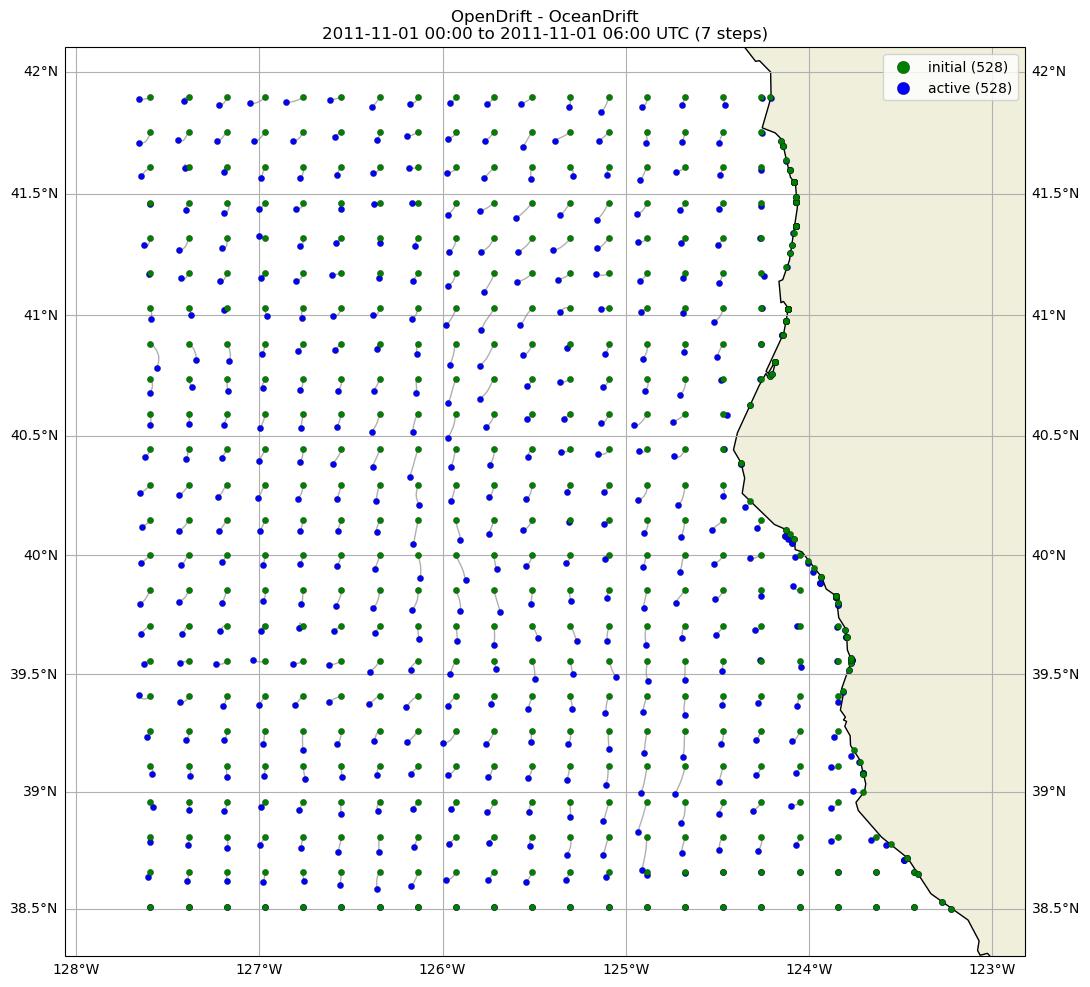

(<GeoAxes: title={'center': 'OpenDrift - OceanDrift\n2011-11-01 00:00 to 2011-11-01 06:00 UTC (7 steps)'}>,
 <Figure size 1100x1045.52 with 1 Axes>)

In [47]:
o.plot()

In [ ]:
for i in tqdm(range(0,int(len(uv_opendrift_ready.time)/6))):
    lcs = o.calculate_ftle( 
        time=reader_data.start_time + timedelta(hours=0+i*6),
        time_step=timedelta(minutes=60),
        duration=timedelta(hours=6), delta_x=1804,delta_y=1624,reader=reader_data,
        RLCS=True)
    lcs_lat = lcs['lat']
    lcs_lon = lcs['lon']
    alcs_time = lcs['time']
    alcs_data = lcs['ALCS'].data
    time = alcs_time
    lat = lcs_lat[:,0]
    lon = lcs_lon[0,:]
    rlcs_data = lcs['RLCS'].data

    ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS')
    RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS')
    LCS = xr.merge([ALCS,RLCS])
    LCS.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/LCS_data_nc/lcs_data_'+str(i).zfill(4)+'.nc')

## Ridge Extraction

### land masking

In [6]:
test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'


In [7]:
# import interpolant
from scipy.interpolate import RectBivariateSpline

# import progress bar
from tqdm.notebook import tqdm

def Ridge_extraction(FTLE, FTLE_threshold, N, ds):
    y_domain = np.array(FTLE.lat)
    x_domain = np.array(FTLE.lon)
    X_domain,Y_domain = np.meshgrid(x_domain,y_domain)
    Interpolant_FTLE = RectBivariateSpline(y_domain, x_domain, FTLE, kx=3, ky=3, s=0)

    x_ridges = X_domain[np.where(np.logical_and(np.array(FTLE)>FTLE_threshold[0],np.array(FTLE)<FTLE_threshold[1]))].ravel()
    y_ridges = Y_domain[np.where(np.logical_and(np.array(FTLE)>FTLE_threshold[0],np.array(FTLE)<FTLE_threshold[1]))].ravel()
    
    for s in tqdm(range(N)):
        dx = x_domain[1]-x_domain[0]
        dy = y_domain[1] - y_domain[0]
        # evaluate the gradient of the FTLE field
        grad_FTLE_x = (Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False)-Interpolant_FTLE(y_ridges, x_ridges-dx, grid = False))/(2*dx)
        grad_FTLE_y = (Interpolant_FTLE(y_ridges+dy, x_ridges, grid = False)-Interpolant_FTLE(y_ridges-dy, x_ridges, grid = False))/(2*dy)
        grad_FTLE = np.sqrt(grad_FTLE_x**2+grad_FTLE_y**2)
        
        x_ridges = x_ridges - ds/(grad_FTLE)*grad_FTLE_x
        y_ridges = y_ridges - ds/(grad_FTLE)*grad_FTLE_y
        
    return x_ridges, y_ridges
    



In [8]:
lcs_files, lcs_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/','LCS_data_nc',file_end='nc')
lcs = xr.open_mfdataset(lcs_filepaths)

In [23]:
lcs_lat = lcs['lat']
lcs_lon = lcs['lon']
alcs_time = lcs['time']
alcs_data = lcs['ALCS'].data
time = alcs_time
lat = lcs_lat[:]
lon = lcs_lon[:]
rlcs_data = lcs['RLCS'].data

ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS')
RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS')



In [26]:
lcs

<xarray.Dataset>
Dimensions:  (time: 1519, lat: 236, lon: 215)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T12:00:00
  * lat      (lat) float64 38.51 38.52 38.54 38.55 ... 41.89 41.9 41.92 41.93
  * lon      (lon) float64 -127.6 -127.6 -127.6 -127.5 ... -123.2 -123.2 -123.2
Data variables:
    ALCS     (time, lat, lon) float64 dask.array<chunksize=(1, 236, 215), meta=np.ndarray>
    RLCS     (time, lat, lon) float64 dask.array<chunksize=(1, 236, 215), meta=np.ndarray>

In [24]:
alcs_mapped = np.where(np.array((Land_mask[:-1,:-1]-1)*-1),ALCS,np.nan)
rlcs_mapped = np.where(np.array((Land_mask[:-1,:-1]-1)*-1),RLCS,np.nan)

alcs_mapped = np.reshape(alcs_mapped,(1,np.shape(alcs_mapped)[1],np.shape(alcs_mapped)[2]))
rlcs_mapped = np.reshape(rlcs_mapped,(1,np.shape(alcs_mapped)[1],np.shape(alcs_mapped)[2]))



ValueError: cannot reshape array of size 77074060 into shape (1,236,215)

In [ ]:
rlcs_mapped

In [ ]:
ALCS = xr.DataArray(alcs_mapped, coords = [time,lat,lon], dims= ['time','lat','lon'],name='ALCS')
RLCS = xr.DataArray(rlcs_mapped, coords = [time,lat,lon], dims= ['time','lat','lon'],name='ALCS')


In [ ]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
ALCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())
#test_uv_proj['u'].isel(time=0).plot()
#coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor='.7')
plt.title("6 hour attracting LCS at " + str(np.array(ALCS.time)[0])[0:13]) 
#ax.add_feature(coast_10m)
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.set_aspect('equal') 
ax.coastlines()
plt.savefig('./lcs_proj.png')

In [ ]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
RLCS.plot(transform=ccrs.PlateCarree())
#test_uv_proj['u'].isel(time=0).plot()
#coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor='.7')
plt.title("6 hour repelling LCS at " + str(np.array(ALCS.time)[0])[0:13]) 
#ax.add_feature(coast_10m)
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.set_aspect('equal') 
ax.coastlines()
plt.savefig('./lcs_proj.png')

In [16]:
lcs_land_mask = np.array((Land_mask.where(Land_mask<1)+1)[1:,1:])

### ridge selection

In [103]:
lcs_model = xr.open_dataset('/media/basil/Elements/data/Thesis/LLC4320/nc_files/cutouts/lcs_cape_mend_landmask.nc')

In [12]:
lcs_model

<xarray.Dataset>
Dimensions:  (time: 1519, lat: 236, lon: 215)
Coordinates:
  * time     (time) datetime64[ns] 2011-11-01 ... 2012-11-14T12:00:00
  * lat      (lat) float64 38.51 38.52 38.54 38.55 ... 41.89 41.9 41.92 41.93
  * lon      (lon) float64 -127.6 -127.6 -127.6 -127.5 ... -123.2 -123.2 -123.2
Data variables:
    ALCS     (time, lat, lon) float64 ...
    RLCS     (time, lat, lon) float64 ...

In [13]:
X = Land_mask[1:,1:].X
Y = Land_mask[1:,1:].Y

In [ ]:
lcs_land_nan = lcs.where(np.isfinite(lcs_land_mask),0)
lcs_land_nan.isel(time=0)

In [32]:
lcs_model.coords['lon'] = X_uniform[:-1]
lcs_model.coords['lat'] = Y_uniform[:-1]
lcs_model = lcs_model.rename({'lon':'X','lat':'Y'})


In [114]:
#fig,ax = plt.subplots(ncols=2, nrows=1,figsize=(14,6))
FTLE_r = lcs_model['RLCS'].isel(time=i)
FTLE_a = lcs_model['ALCS'].isel(time=i)
FTLE_threshold_a = [1e-5,1e-4]
FTLE_threshold = [-3e-5,0]
#FTLE.plot()
FTLE_r = FTLE_r.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]),0)#.plot(ax=ax[0])

FTLE_a = FTLE_a.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold_a[0],np.array(FTLE_a)<FTLE_threshold_a[1]),0)#.plot(ax=ax[1])


In [115]:
#attr
y_domain = np.array(FTLE_r.lat)
#FTLE_threshold = [-6e-5,0] #Repelling
FTLE_threshold = [1e-5,1e-4] #Attracting
x_domain = np.array(FTLE_r.lon)
X_domain,Y_domain = np.meshgrid(x_domain,y_domain)
dx = x_domain[1]-x_domain[0]
dy = y_domain[1] - y_domain[0]

Interpolant_FTLE = RectBivariateSpline(y_domain, x_domain, np.array(FTLE_a), kx=3, ky=3, s=0)
x_ridges = X_domain[np.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold[0],np.array(FTLE_a)<FTLE_threshold[1]))]
y_ridges = Y_domain[np.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold[0],np.array(FTLE_a)<FTLE_threshold[1]))]
x_ridges[~np.isfinite(x_ridges)] = 0
y_ridges[~np.isfinite(y_ridges)] = 0
grad_FTLE_x = (Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False)-Interpolant_FTLE(y_ridges, x_ridges-dx, grid = False))/(2*dx)
grad_FTLE_y = (Interpolant_FTLE(y_ridges+dy, x_ridges, grid = False)-Interpolant_FTLE(y_ridges-dy, x_ridges, grid = False))/(2*dy)
grad_FTLE = np.sqrt(grad_FTLE_x**2+grad_FTLE_y**2)
ds=1e-6
x_ridges_a = x_ridges - ds/(grad_FTLE)*grad_FTLE_x
y_ridges_a = y_ridges - ds/(grad_FTLE)*grad_FTLE_y



array([ 1.32055441e-25,  6.79578121e-09,  3.21285356e-09, ...,
       -9.39077983e-10, -2.01357892e-09, -4.74350692e-09])

In [116]:
#rep
y_domain = np.array(FTLE_r.lat)
FTLE_threshold = [-3e-5,0] #Repelling

#FTLE_threshold = [1e-5,1e-4] #Attracting
x_domain = np.array(FTLE_r.lon)
X_domain,Y_domain = np.meshgrid(x_domain,y_domain)
dx = x_domain[1]-x_domain[0]
dy = y_domain[1] - y_domain[0]

Interpolant_FTLE = RectBivariateSpline(y_domain, x_domain, np.array(FTLE_r), kx=3, ky=3, s=0)
x_ridges = X_domain[np.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]))]
y_ridges = Y_domain[np.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]))]
x_ridges[~np.isfinite(x_ridges)] = 0
y_ridges[~np.isfinite(y_ridges)] = 0
grad_FTLE_x = (Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False)-Interpolant_FTLE(y_ridges, x_ridges-dx, grid = False))/(2*dx)
grad_FTLE_y = (Interpolant_FTLE(y_ridges+dy, x_ridges, grid = False)-Interpolant_FTLE(y_ridges-dy, x_ridges, grid = False))/(2*dy)
grad_FTLE = np.sqrt(grad_FTLE_x**2+grad_FTLE_y**2)
ds=1e-6
x_ridges_r = x_ridges - ds/(grad_FTLE)*grad_FTLE_x
y_ridges_r = y_ridges - ds/(grad_FTLE)*grad_FTLE_y

In [47]:
np.isfinite(Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False))

0

In [113]:
dx

0.020645339246343042

Text(0, 0.5, 'Y')

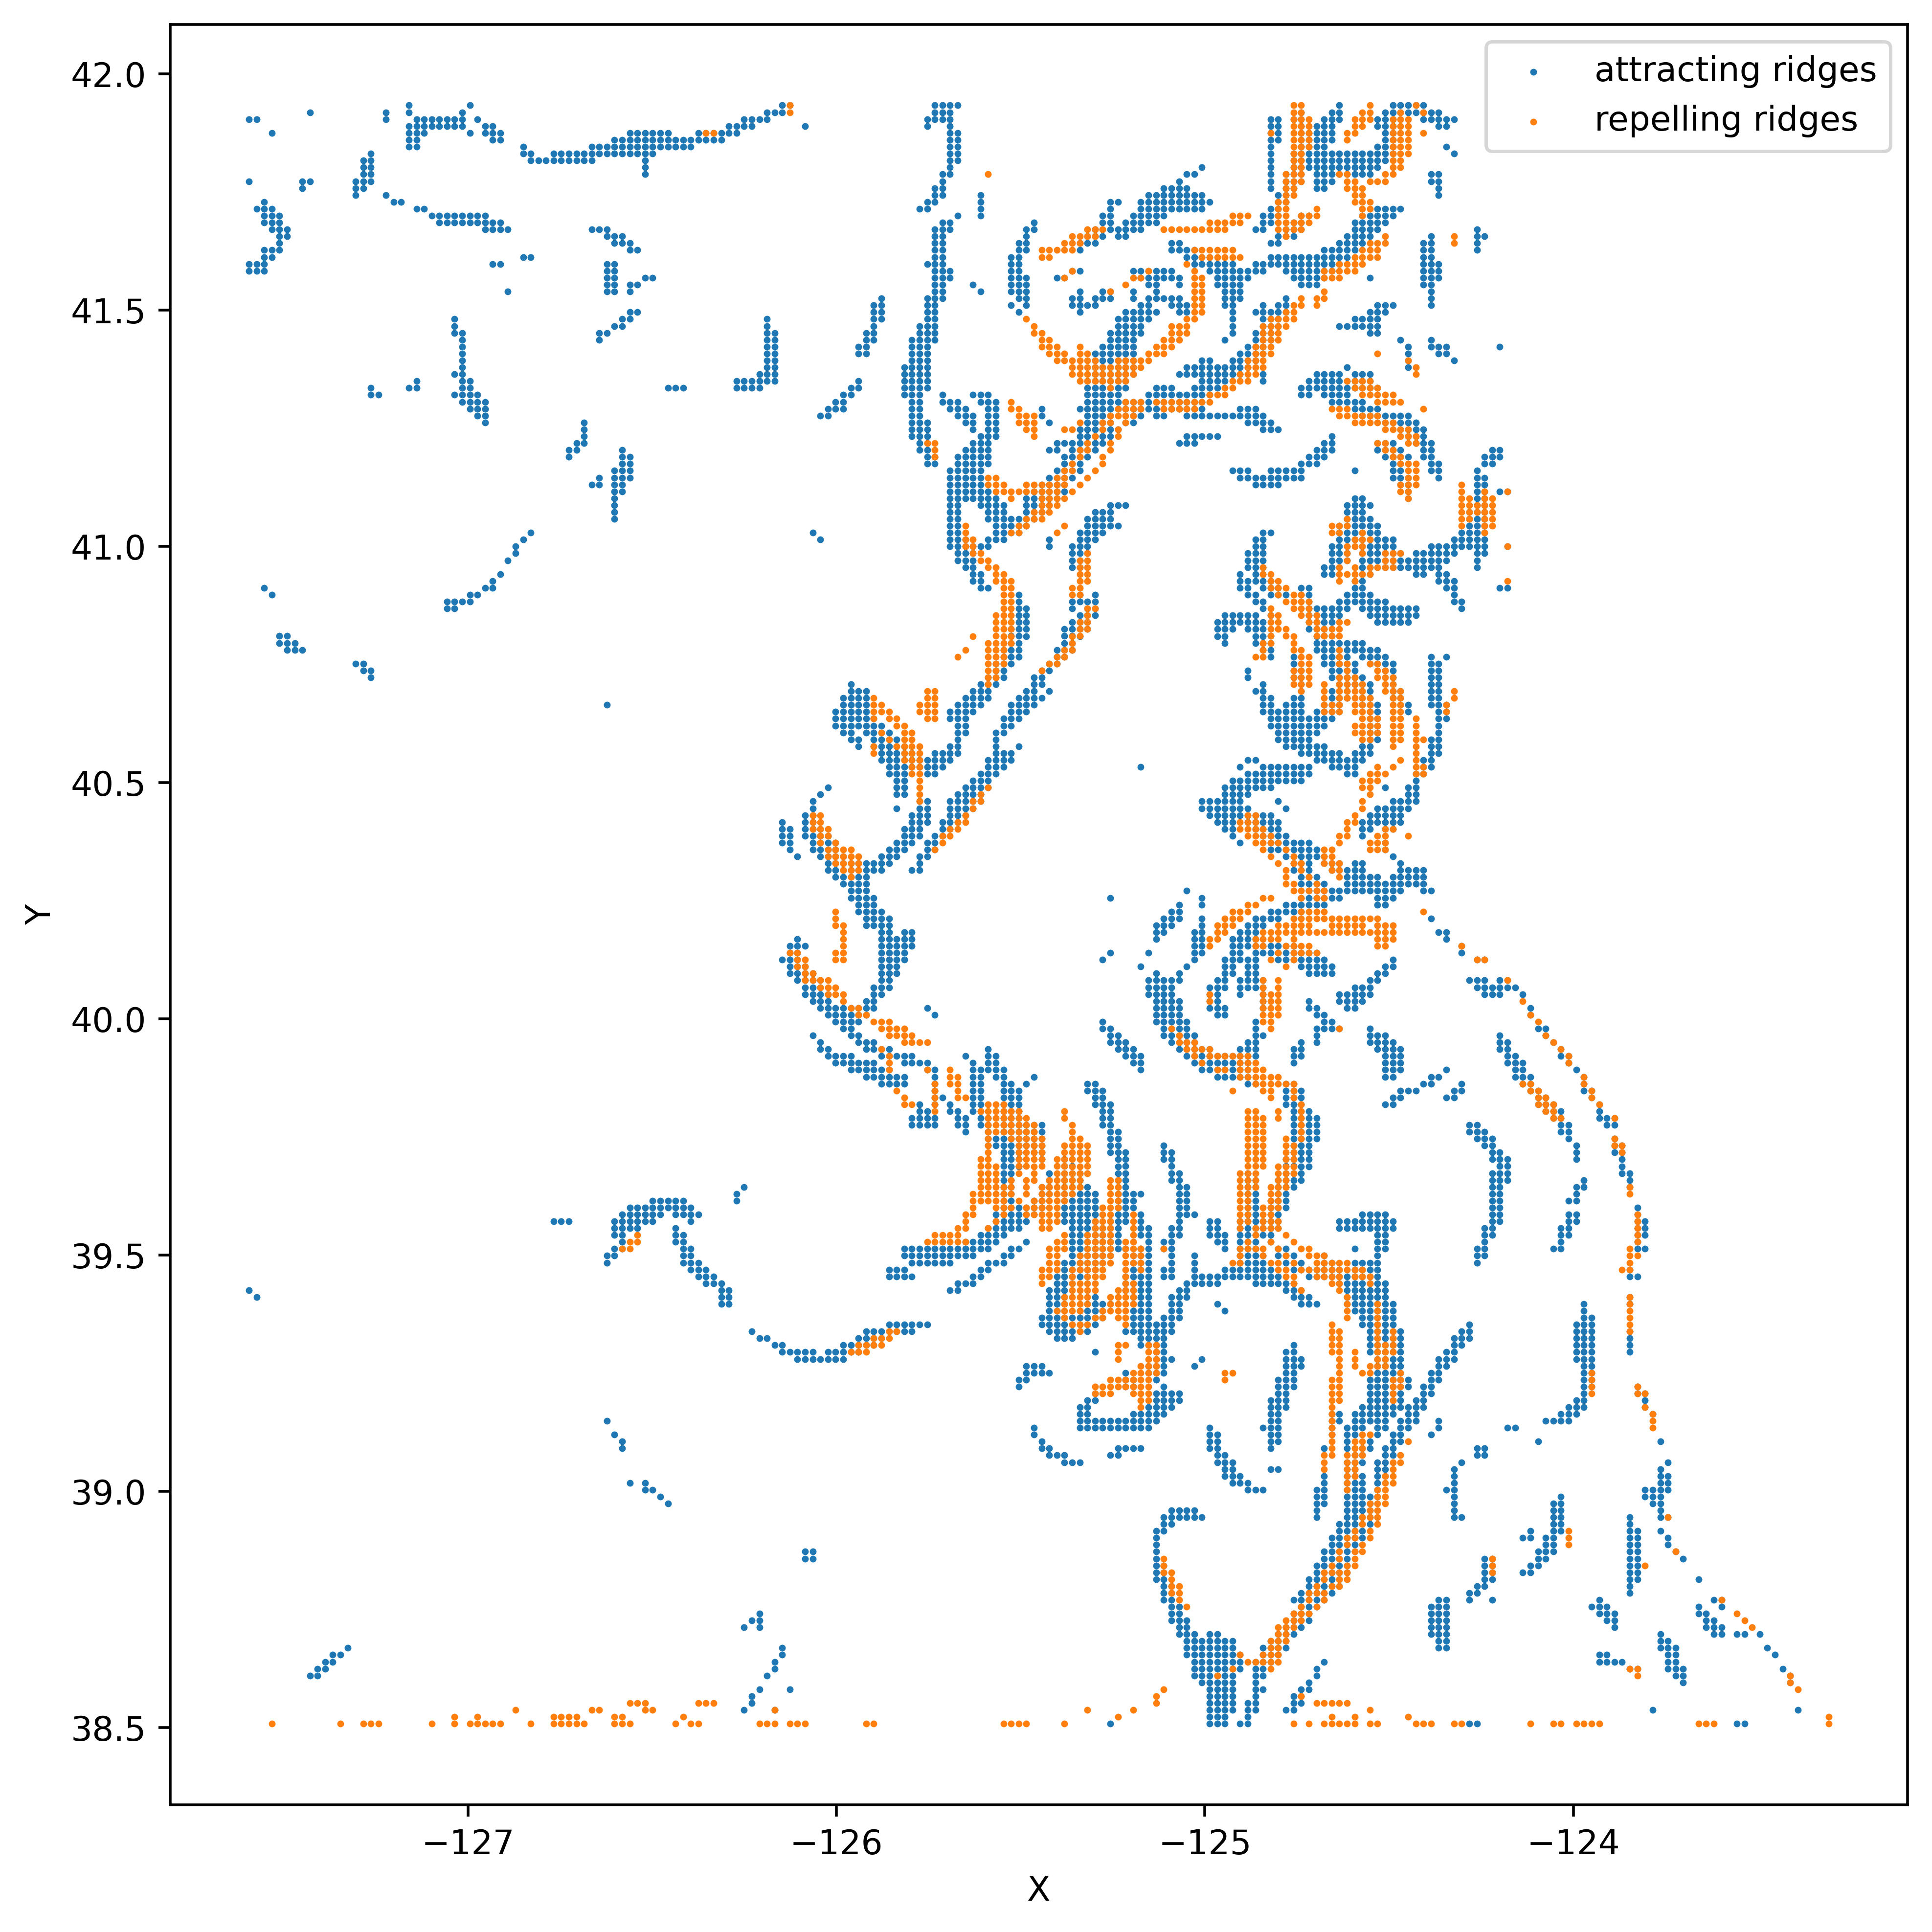

In [117]:
ds=1e-6
fig = plt.figure(figsize = (8,8), dpi = 500)
ax = plt.axes()

ax.scatter(x_ridges_a, y_ridges_a, s = 1,label= 'attracting ridges')
ax.scatter(x_ridges_r, y_ridges_r, s = 1,label= 'repelling ridges')
ax.legend()
# Axis Labels
ax.set_xlabel("X", fontsize = 10)
ax.set_ylabel("Y", fontsize = 10)

Text(0, 0.5, 'Y')

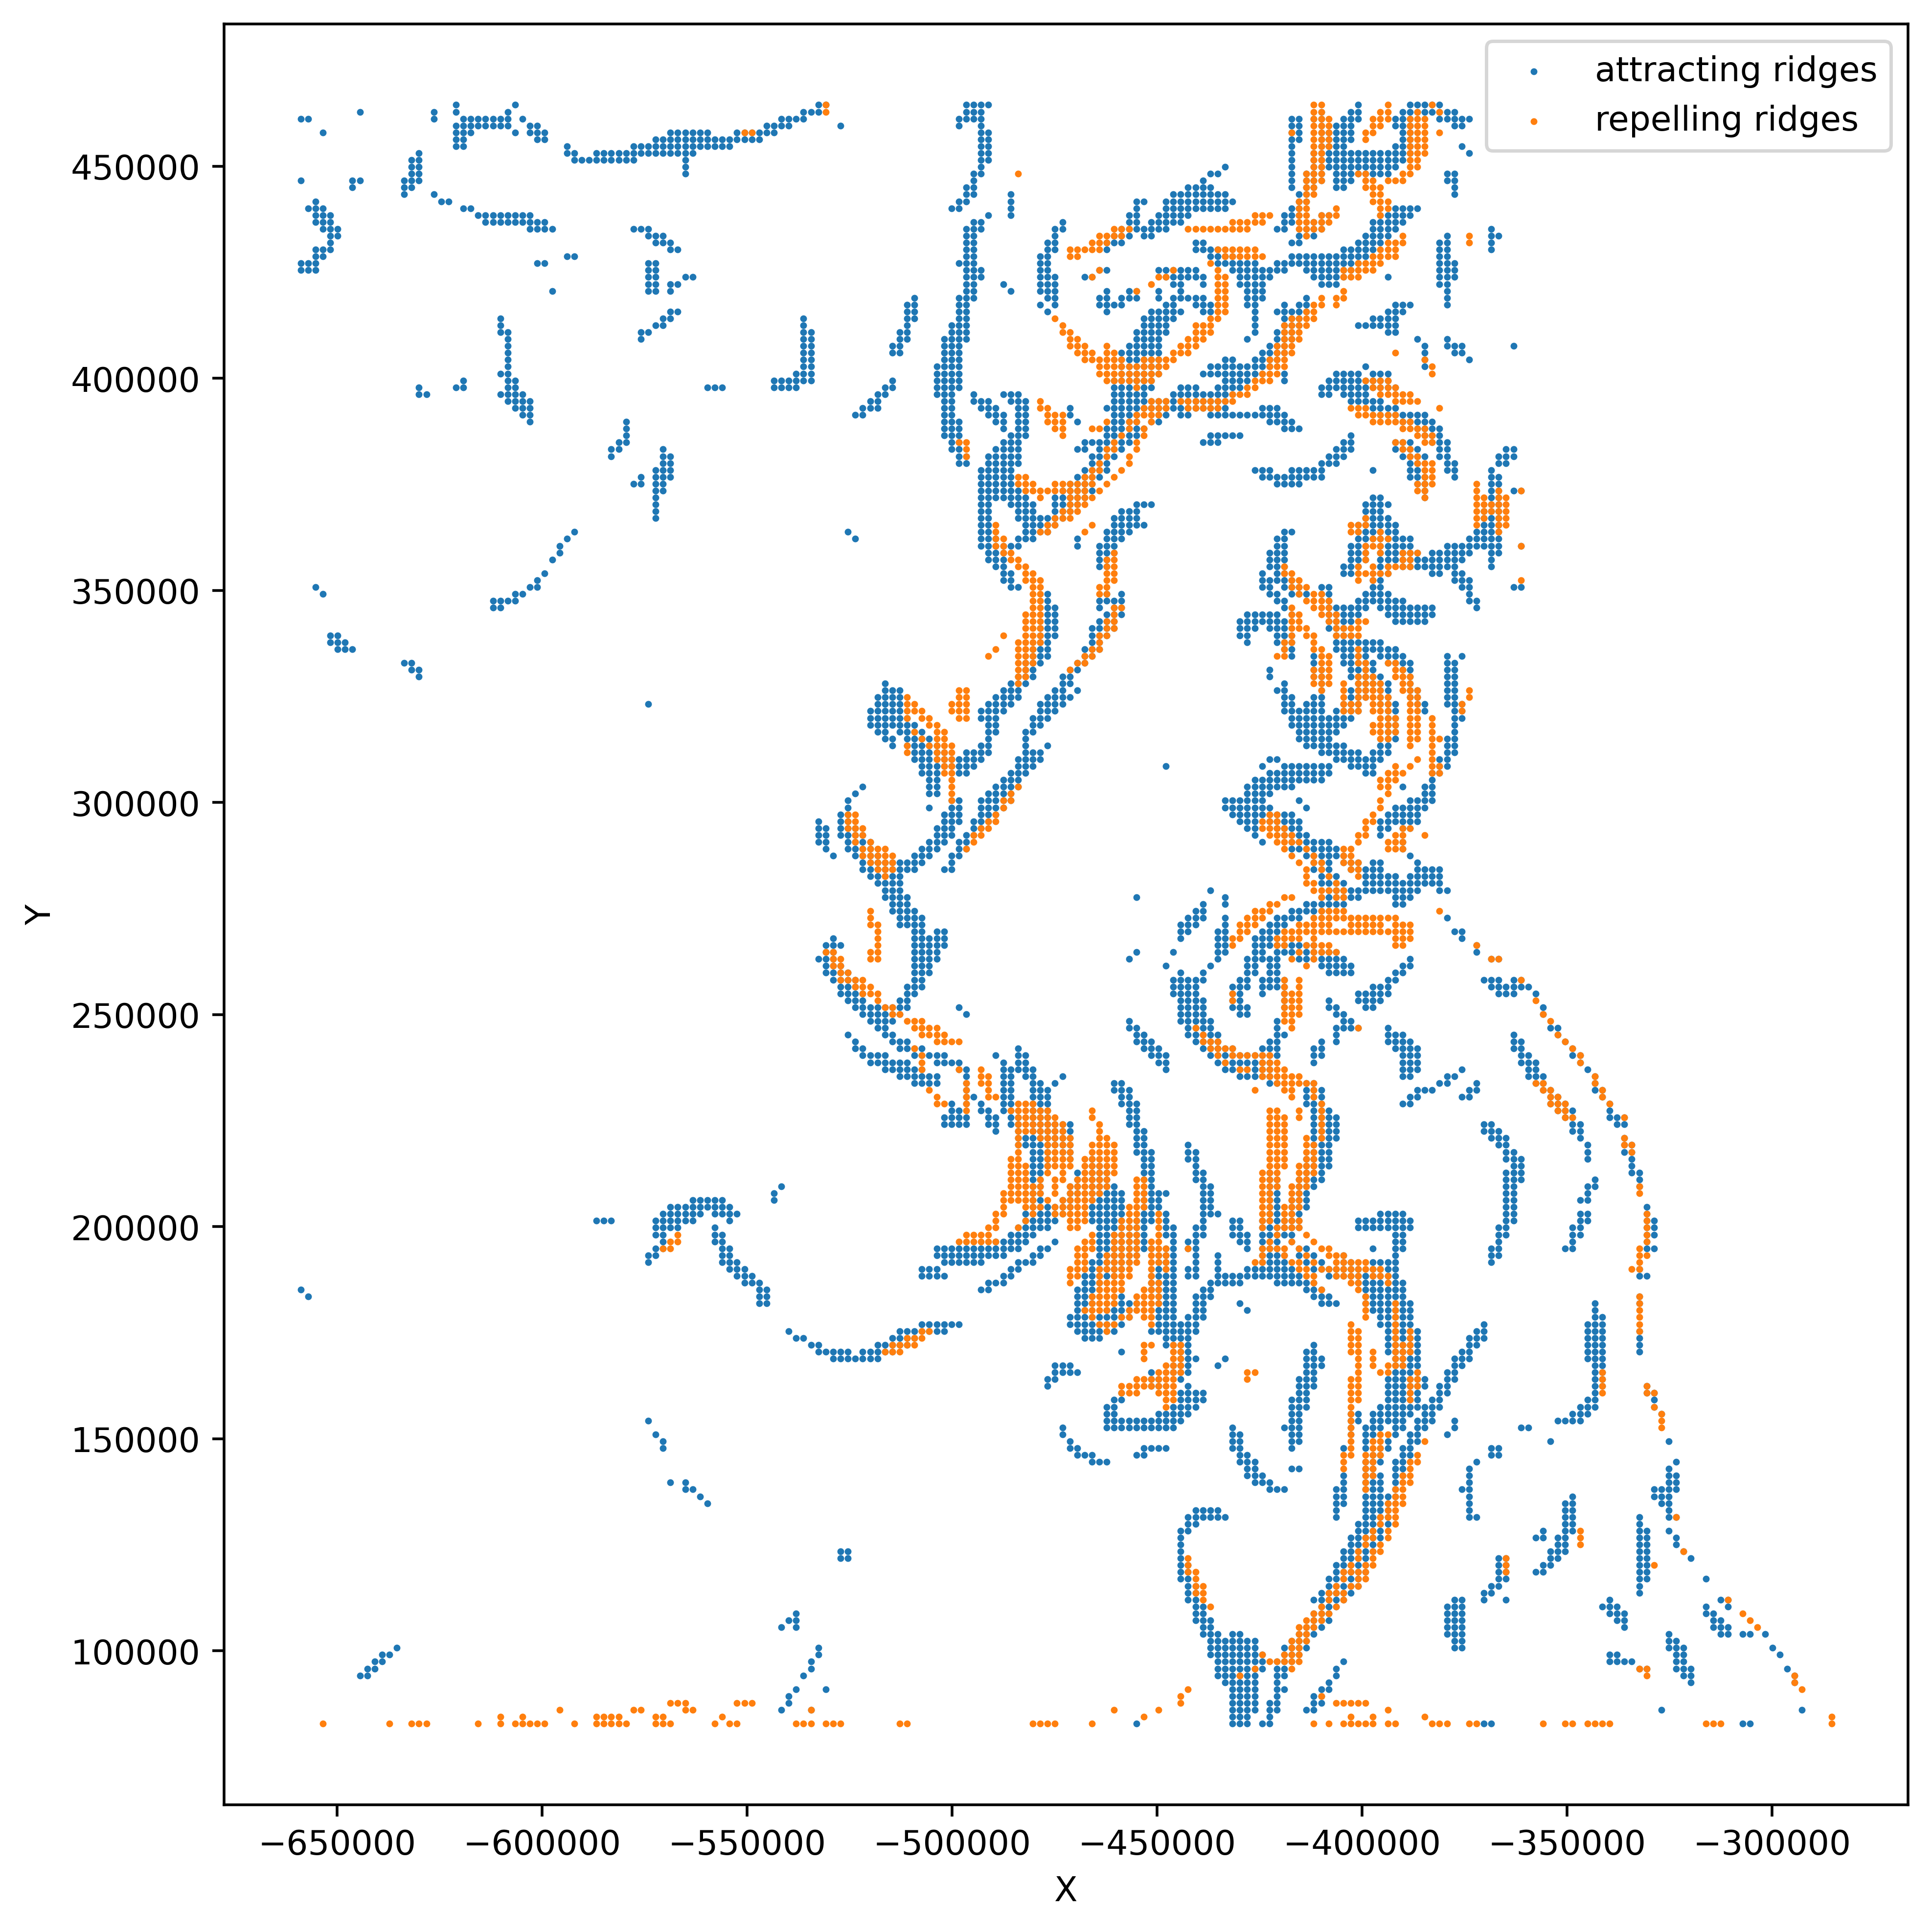

In [94]:
ds=1e-5
fig = plt.figure(figsize = (8,8), dpi = 500)
ax = plt.axes()

ax.scatter(x_ridges_a, y_ridges_a, s = 1,label= 'attracting ridges')
ax.scatter(x_ridges_r, y_ridges_r, s = 1,label= 'repelling ridges')
ax.legend()
# Axis Labels
ax.set_xlabel("X", fontsize = 10)
ax.set_ylabel("Y", fontsize = 10)

In [107]:
#convert back to lat/lon
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs, target_crs)
proj_in_y, proj_in_x = latlon_to_polar.transform(x_ridges_r, y_ridges_r)


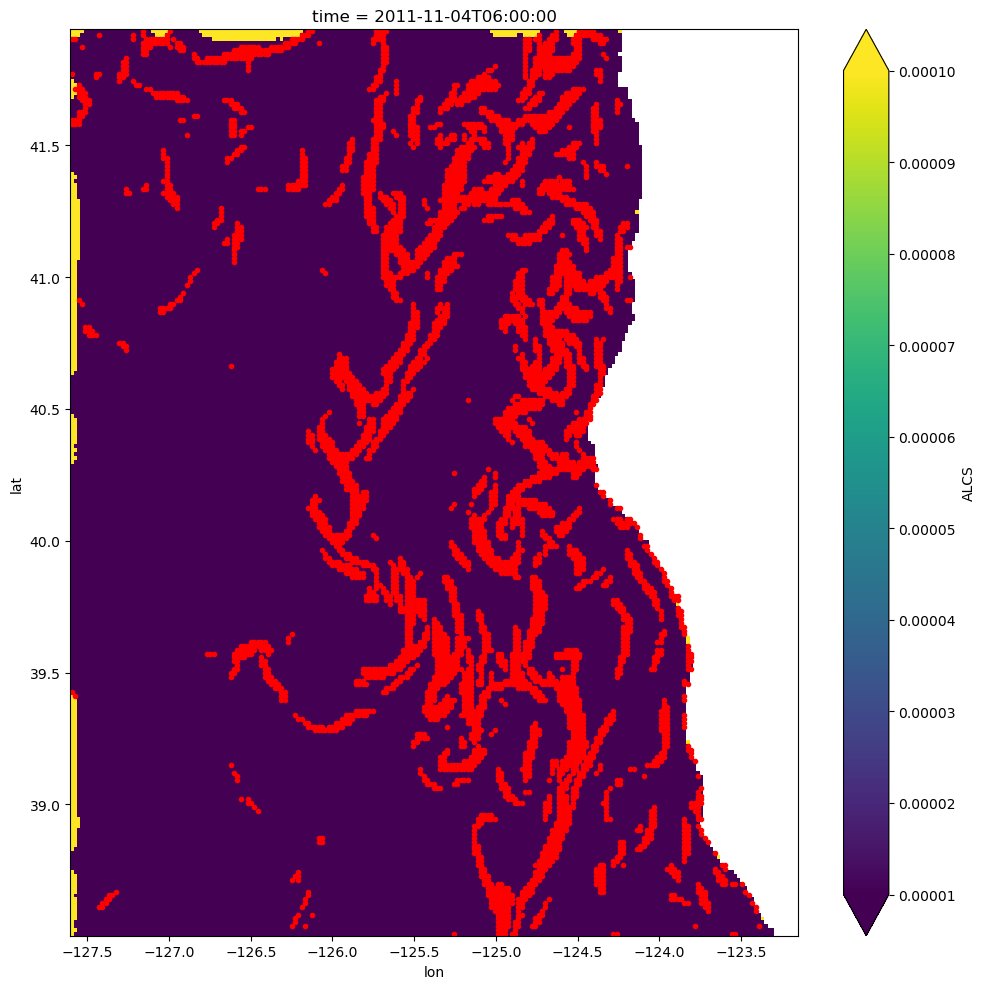

In [122]:
FTLE_r = lcs_model['RLCS'].isel(time=13)
FTLE_a = lcs_model['ALCS'].isel(time=13)
FTLE_threshold_a = [1e-5,1e-4]
FTLE_threshold = [-3e-5,0]
#FTLE.plot()
FTLE_r_nan = FTLE_r.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]),0)#.plot(ax=ax[0])

FTLE_a_nan = FTLE_a.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold_a[0],np.array(FTLE_a)<FTLE_threshold_a[1]),0)#.plot(ax=ax[1])
plt.figure(figsize=(10,10))
FTLE_a.plot(vmin=FTLE_threshold_a[0],vmax=FTLE_threshold_a[1] )
plt.plot(x_ridges_a,y_ridges_a, 'r.')

  0%|          | 0/4000 [00:00<?, ?it/s]

In [181]:
FTLE_threshold_a = [1e-5,1e-4]
FTLE_threshold = [-3e-5,0]
y_domain = np.array(FTLE_r.lat)

for i in tqdm(range(0,len(lcs_model.time))):
    
    FTLE_r = lcs_model['RLCS'].isel(time=i)
    FTLE_a = lcs_model['ALCS'].isel(time=i)
    #FTLE.plot()
    FTLE_r = FTLE_r.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]),0)#.plot(ax=ax[0])
    
    FTLE_a = FTLE_a.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold_a[0],np.array(FTLE_a)<FTLE_threshold_a[1]),0)#.plot(ax=ax[1])
    #arracting ridges
    y_domain = np.array(FTLE_r.lat)
    #FTLE_threshold = [-6e-5,0] #Repelling
    x_domain = np.array(FTLE_r.lon)
    X_domain,Y_domain = np.meshgrid(x_domain,y_domain)
    dx = x_domain[1]-x_domain[0]
    dy = y_domain[1] - y_domain[0]
    
    Interpolant_FTLE = RectBivariateSpline(y_domain, x_domain, np.array(FTLE_a), kx=3, ky=3, s=0)
    x_ridges = X_domain[np.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold_a[0],np.array(FTLE_a)<FTLE_threshold_a[1]))]
    y_ridges = Y_domain[np.where(np.logical_and(np.array(FTLE_a)>FTLE_threshold_a[0],np.array(FTLE_a)<FTLE_threshold_a[1]))]
    x_ridges[~np.isfinite(x_ridges)] = 0
    y_ridges[~np.isfinite(y_ridges)] = 0
    grad_FTLE_x = (Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False)-Interpolant_FTLE(y_ridges, x_ridges-dx, grid = False))/(2*dx)
    grad_FTLE_y = (Interpolant_FTLE(y_ridges+dy, x_ridges, grid = False)-Interpolant_FTLE(y_ridges-dy, x_ridges, grid = False))/(2*dy)
    grad_FTLE = np.sqrt(grad_FTLE_x**2+grad_FTLE_y**2)
    ds=1e-6
    x_ridges_a = x_ridges - ds/(grad_FTLE)*grad_FTLE_x
    y_ridges_a = y_ridges - ds/(grad_FTLE)*grad_FTLE_y
    #repelling
    
    Interpolant_FTLE = RectBivariateSpline(y_domain, x_domain, np.array(FTLE_r), kx=3, ky=3, s=0)
    x_ridges = X_domain[np.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]))]
    y_ridges = Y_domain[np.where(np.logical_and(np.array(FTLE_r)>FTLE_threshold[0],np.array(FTLE_r)<FTLE_threshold[1]))]
    x_ridges[~np.isfinite(x_ridges)] = 0
    y_ridges[~np.isfinite(y_ridges)] = 0
    grad_FTLE_x = (Interpolant_FTLE(y_ridges, x_ridges+dx, grid = False)-Interpolant_FTLE(y_ridges, x_ridges-dx, grid = False))/(2*dx)
    grad_FTLE_y = (Interpolant_FTLE(y_ridges+dy, x_ridges, grid = False)-Interpolant_FTLE(y_ridges-dy, x_ridges, grid = False))/(2*dy)
    grad_FTLE = np.sqrt(grad_FTLE_x**2+grad_FTLE_y**2)
    ds=1e-6
    x_ridges_r = x_ridges - ds/(grad_FTLE)*grad_FTLE_x
    y_ridges_r = y_ridges - ds/(grad_FTLE)*grad_FTLE_y
    attracting_structures = np.column_stack([x_ridges_a,y_ridges_a]) 
    repelling_structures=  np.column_stack( [x_ridges_r,y_ridges_r])
    attracting_structures = np.reshape(attracting_structures,(1,len(attracting_structures[:,0]),2))
    repelling_structures = np.reshape(repelling_structures,(1,len(repelling_structures[:,0]),2))
    time = np.array([np.array(lcs_model.time[i])])
    lon_lat = ['lon','lat']
    points_attracting = np.arange(len(attracting_structures[0,:,0]))
    points_repelling = np.arange(len(repelling_structures[0,:,0]))
    attracting_structures = xr.DataArray(attracting_structures, dims=['time','points','lon_lat'], coords = [time,points_attracting,lon_lat],name= 'attracting_structures')
    repelling_structures = xr.DataArray(repelling_structures, dims=['time','points','lon_lat'], coords = [time,points_repelling,lon_lat],name= 'repelling_structures')
    attracting_structures.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/lcs_ridges/attracting/attr_points_'+str(i).zfill(4)+'.nc')
    repelling_structures.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/lcs_ridges/repelling/repp_points_'+str(i).zfill(4)+'.nc')

  0%|          | 0/1519 [00:00<?, ?it/s]

In [173]:
# attracting_structures = np.column_stack([x_ridges_a,y_ridges_a]) 
# repelling_structures=  np.column_stack( [x_ridges_r,y_ridges_r])
# attracting_structures = np.reshape(attracting_structures,(1,len(attracting_structures[:,0]),2))
# repelling_structures = np.reshape(repelling_structures,(1,len(repelling_structures[:,0]),2))
# time = np.array([np.array(time[i])])
# lon_lat = ['lon','lat']
# points_attracting = np.arange(len(attracting_structures[0,:,0]))
# points_repelling = np.arange(len(repelling_structures[0,:,0]))
# attracting_structures = xr.DataArray(attracting_structures, dims=['time','points','lon_lat'], coords = [time,points_attracting,lon_lat],name= 'attracting_structures')
# repelling_structures = xr.DataArray(repelling_structures, dims=['time','points','lon_lat'], coords = [time,points_repelling,lon_lat],name= 'repelling_structures')


<xarray.DataArray 'attracting_structures' (points: 5049, lon_lat: 2)>
array([[-125.25671342,   38.50840892],
       [-124.98738833,   38.50840776],
       [-124.96666744,   38.50840839],
       ...,
       [-124.44849732,   41.93348169],
       [-124.42776434,   41.93348215],
       [-124.40703136,   41.9334829 ]])
Coordinates:
    time     datetime64[ns] 2011-11-01
  * points   (points) int64 0 1 2 3 4 5 6 ... 5042 5043 5044 5045 5046 5047 5048
  * lon_lat  (lon_lat) <U3 'lon' 'lat'

In [153]:
np.shape(attracting_structures)

(5049, 2)

In [166]:
np.array([np.array(time[i])])

array(['2011-11-01T00:00:00.000000000'], dtype='datetime64[ns]')

In [180]:
np.array([np.array(lcs_model.time[i])])

array(['2011-11-01T06:00:00.000000000'], dtype='datetime64[ns]')

In [ ]:
for i in range(0,len(lcs_files)):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(15, 8))
    ax = plt.axes(projection=proj)
    lcs['ALCS'].isel(time=i).plot(vmin=1e-7, vmax=1e-4)
    coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
    plt.title("6 hour attracting LCS at" + str(np.array(lcs.time)[i]) ) 
    ax.add_feature(coast_10m)
    gl = ax.gridlines(draw_labels=True)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    plt.savefig('/media/basil/Elements/data/Thesis/LLC4320/animations/panels/lcs_test/test_anim_'+str(i)+'_.png')